In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

PROCESSED = Path("../data/processed")
RAW       = Path("../data/raw")
CHARTS    = Path("../reports/charts")
CHARTS.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 120

RF = 0.065 / 252   # RBI repo rate 6.5% → daily risk-free rate

print("Setup complete | Rf (daily) =", round(RF, 6))

Setup complete | Rf (daily) = 0.000258


In [2]:
nav   = pd.read_csv(PROCESSED / "clean_nav.csv", parse_dates=['date'])
funds = pd.read_csv(RAW / "01_fund_master.csv")
bench = pd.read_csv(RAW / "10_benchmark_indices.csv", parse_dates=['date'])

# Check benchmark columns
print("Benchmark columns:", bench.columns.tolist())
print(bench.head(3))
print(f"\nNAV shape: {nav.shape}")
print(f"Funds: {funds['amfi_code'].nunique()} schemes")

Benchmark columns: ['date', 'index_name', 'close_value']
        date index_name  close_value
0 2022-01-03    NIFTY50     17492.79
1 2022-01-04    NIFTY50     17689.64
2 2022-01-05    NIFTY50     17835.05

NAV shape: (46000, 4)
Funds: 40 schemes


In [4]:
# Sort first — critical!
nav = nav.sort_values(['amfi_code', 'date']).reset_index(drop=True)

# Compute daily return per fund
nav['daily_return'] = (nav.groupby('amfi_code')['nav']
                          .pct_change())   # pct_change = nav_t/nav_t-1 - 1

# Validate: returns should be mostly in -0.10 to +0.10 range
print("Daily return stats:")
print(nav['daily_return'].describe())
print(f"\nReturns outside ±10%: {(nav['daily_return'].abs() > 0.10).sum()} rows")
print(f"Null returns (first row of each fund): {nav['daily_return'].isna().sum()}")

# Drop nulls (first row of each fund has no previous NAV)
returns_df = nav.dropna(subset=['daily_return']).copy()
print(f"\n returns_df shape: {returns_df.shape}")

# Save
returns_df.to_csv(PROCESSED / "returns_computed.csv", index=False)
print(" Saved returns_computed.csv")

Daily return stats:
count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

Returns outside ±10%: 0 rows
Null returns (first row of each fund): 40

 returns_df shape: (45960, 5)
 Saved returns_computed.csv


In [5]:
from datetime import timedelta

def compute_cagr(group, years):
    """Compute CAGR for a fund over given number of years."""
    end_date   = group['date'].max()
    start_date = end_date - pd.DateOffset(years=years)

    # Get closest available dates
    end_nav   = group.loc[group['date'] == group['date'].max(), 'nav']
    start_nav = group.loc[group['date'] >= start_date, 'nav']

    if len(start_nav) == 0 or len(end_nav) == 0:
        return np.nan

    nav_start = start_nav.iloc[0]
    nav_end   = end_nav.iloc[0]

    if nav_start <= 0:
        return np.nan

    n = years  # number of years
    cagr = (nav_end / nav_start) ** (1 / n) - 1
    return round(cagr * 100, 2)  # return as %

# Compute for each fund
cagr_results = []
for code, group in nav.groupby('amfi_code'):
    row = {'amfi_code': code}
    row['cagr_1yr_pct']  = compute_cagr(group, 1)
    row['cagr_3yr_pct']  = compute_cagr(group, 3)
    row['cagr_5yr_pct']  = compute_cagr(group, 5)
    cagr_results.append(row)

cagr_df = pd.DataFrame(cagr_results)
cagr_df = cagr_df.merge(funds[['amfi_code','scheme_name','fund_house','category']], on='amfi_code')

print(cagr_df[['scheme_name','cagr_1yr_pct','cagr_3yr_pct','cagr_5yr_pct']].to_string())
cagr_df.to_csv(PROCESSED / "cagr_report.csv", index=False)
print("\n Saved cagr_report.csv")

                                              scheme_name  cagr_1yr_pct  cagr_3yr_pct  cagr_5yr_pct
0               HDFC Top 100 Fund - Regular Plan - Growth         -2.22          1.29          2.32
1            HDFC Short Term Debt Fund - Regular - Growth          3.70          3.92          3.91
2      HDFC Mid-Cap Opportunities Fund - Regular - Growth         53.23         32.44         26.07
3           ABSL Frontline Equity Fund - Regular - Growth         47.92         28.97         20.44
4                  ABSL Small Cap Fund - Regular - Growth        -23.99         -4.15          6.95
5                     ABSL Liquid Fund - Regular - Growth          7.24          6.32          5.71
6              UTI Nifty 50 Index Fund - Regular - Growth         20.21         19.67         15.88
7                     UTI Mid Cap Fund - Regular - Growth        -16.80         -0.77          1.03
8                   UTI Flexi Cap Fund - Regular - Growth         13.58         25.56         14.68


In [6]:
sharpe_results = []

for code, group in returns_df.groupby('amfi_code'):
    r = group['daily_return']

    mean_r  = r.mean()
    std_r   = r.std()

    if std_r == 0 or np.isnan(std_r):
        sharpe = np.nan
    else:
        sharpe = (mean_r - RF) / std_r * np.sqrt(252)

    sharpe_results.append({
        'amfi_code':   code,
        'mean_daily_return': round(mean_r, 6),
        'std_daily_return':  round(std_r, 6),
        'sharpe_ratio':      round(sharpe, 4),
        'annualised_return_pct': round(mean_r * 252 * 100, 2),
    })

sharpe_df = pd.DataFrame(sharpe_results)
sharpe_df = sharpe_df.merge(funds[['amfi_code','scheme_name','fund_house']], on='amfi_code')

# Rank all 40 funds
sharpe_df['sharpe_rank'] = sharpe_df['sharpe_ratio'].rank(ascending=False).astype(int)
sharpe_df = sharpe_df.sort_values('sharpe_rank')

print(sharpe_df[['scheme_name','sharpe_ratio','sharpe_rank']].head(10).to_string())
sharpe_df.to_csv(PROCESSED / "sharpe_values.csv", index=False)
print("\n Saved sharpe_values.csv")

                                           scheme_name  sharpe_ratio  sharpe_rank
34       Mirae Asset Large Cap Fund - Regular - Growth        1.4483            1
30              Kotak Flexicap Fund - Regular - Growth        1.3067            2
36       Mirae Asset Tax Saver Fund - Regular - Growth        1.2349            3
19           SBI Bluechip Fund - Regular Plan - Growth        1.2083            4
25            ICICI Pru Midcap Fund - Regular - Growth        1.1801            5
38                  DSP Midcap Fund - Regular - Growth        1.1321            6
2   HDFC Mid-Cap Opportunities Fund - Regular - Growth        1.0937            7
9       Nippon India Large Cap Fund - Regular - Growth        1.0817            8
3        ABSL Frontline Equity Fund - Regular - Growth        1.0272            9
24           ICICI Pru Bluechip Fund - Direct - Growth        1.0265           10

 Saved sharpe_values.csv


In [7]:
sortino_results = []

for code, group in returns_df.groupby('amfi_code'):
    r = group['daily_return']

    mean_r = r.mean()

    # Downside: only negative return days
    negative_returns = r[r < 0]
    downside_std = negative_returns.std()

    if downside_std == 0 or np.isnan(downside_std):
        sortino = np.nan
    else:
        sortino = (mean_r - RF) / downside_std * np.sqrt(252)

    sortino_results.append({
        'amfi_code':     code,
        'sortino_ratio': round(sortino, 4),
        'downside_std':  round(downside_std, 6),
        'negative_days': len(negative_returns),
    })

sortino_df = pd.DataFrame(sortino_results)
sortino_df = sortino_df.merge(funds[['amfi_code','scheme_name']], on='amfi_code')
sortino_df['sortino_rank'] = sortino_df['sortino_ratio'].rank(ascending=False).astype(int)
sortino_df = sortino_df.sort_values('sortino_rank')

print(sortino_df[['scheme_name','sortino_ratio','negative_days']].head(10).to_string())
sortino_df.to_csv(PROCESSED / "sortino_values.csv", index=False)
print("\n Saved sortino_values.csv")

                                           scheme_name  sortino_ratio  negative_days
34       Mirae Asset Large Cap Fund - Regular - Growth         2.3856            506
30              Kotak Flexicap Fund - Regular - Growth         2.3643            534
36       Mirae Asset Tax Saver Fund - Regular - Growth         2.1469            545
19           SBI Bluechip Fund - Regular Plan - Growth         2.1403            518
25            ICICI Pru Midcap Fund - Regular - Growth         2.0294            539
38                  DSP Midcap Fund - Regular - Growth         1.8751            526
9       Nippon India Large Cap Fund - Regular - Growth         1.8501            532
2   HDFC Mid-Cap Opportunities Fund - Regular - Growth         1.8291            538
24           ICICI Pru Bluechip Fund - Direct - Growth         1.8053            517
3        ABSL Frontline Equity Fund - Regular - Growth         1.7996            539

 Saved sortino_values.csv


In [8]:
from scipy.stats import linregress

# Prepare benchmark — get Nifty 100 column
# Check exact column name:
print(bench.columns.tolist())
print(bench['index_name'].unique() if 'index_name' in bench.columns else "No index_name col")

['date', 'index_name', 'close_value']
['NIFTY50' 'NIFTY100' 'NIFTY_MIDCAP150' 'BSE_SMALLCAP' 'NIFTY500'
 'CRISIL_LIQUID' 'CRISIL_GILT']


In [10]:
print(bench.columns.tolist())
print(bench.head())

['date', 'index_name', 'close_value']
        date index_name  close_value
0 2022-01-03    NIFTY50     17492.79
1 2022-01-04    NIFTY50     17689.64
2 2022-01-05    NIFTY50     17835.05
3 2022-01-06    NIFTY50     17878.51
4 2022-01-07    NIFTY50     17759.15


In [11]:
print(len(nifty100))
print(nifty100.head())

0
Empty DataFrame
Columns: [date, index_name, close_value]
Index: []


In [13]:
from scipy.stats import linregress
import pandas as pd

# =========================
# Prepare Benchmark Returns
# =========================

print("Available Benchmarks:")
print(bench['index_name'].unique())

# Use NIFTY100 if available, otherwise switch to NIFTY50
nifty100 = bench[bench['index_name'] == 'NIFTY100'].copy()

# If NIFTY100 doesn't exist, uncomment below:
# nifty100 = bench[bench['index_name'] == 'NIFTY50'].copy()

nifty100['date'] = pd.to_datetime(nifty100['date'])
nifty100 = nifty100.sort_values('date')

# Calculate benchmark daily returns
nifty100['bench_return'] = nifty100['close_value'].pct_change()

# Remove first NaN row
nifty100 = nifty100.dropna(subset=['bench_return'])

print(f"Benchmark rows available: {len(nifty100)}")

# =========================
# Alpha & Beta Calculation
# =========================

alpha_beta_results = []

for code, group in returns_df.groupby('amfi_code'):

    # Merge fund returns with benchmark returns
    merged = group[['date', 'daily_return']].merge(
        nifty100[['date', 'bench_return']],
        on='date',
        how='inner'
    )

    # Skip if insufficient observations
    if len(merged) < 30:
        continue

    x = merged['bench_return']
    y = merged['daily_return']

    slope, intercept, r_value, p_value, std_err = linregress(x, y)

    alpha_annualised = intercept * 252

    alpha_beta_results.append({
        'amfi_code': code,
        'beta': round(slope, 4),
        'alpha_annual': round(alpha_annualised * 100, 4),
        'r_squared': round(r_value ** 2, 4),
        'p_value': round(p_value, 4),
        'data_points': len(merged)
    })

# =========================
# Create Final DataFrame
# =========================

ab_df = pd.DataFrame(alpha_beta_results)

ab_df = ab_df.merge(
    funds[['amfi_code', 'scheme_name', 'fund_house']],
    on='amfi_code',
    how='left'
)

# Add category only if it exists
if 'category' in funds.columns:
    ab_df = ab_df.merge(
        funds[['amfi_code', 'category']],
        on='amfi_code',
        how='left'
    )

ab_df = ab_df.sort_values(
    by='alpha_annual',
    ascending=False
)

# =========================
# Output Results
# =========================

print("\nTop 10 Funds by Alpha:\n")

cols = ['scheme_name', 'alpha_annual', 'beta', 'r_squared']

if 'category' in ab_df.columns:
    cols.insert(1, 'category')

print(ab_df[cols].head(10).to_string(index=False))

# Save CSV
ab_df.to_csv(
    PROCESSED / "alpha_beta.csv",
    index=False
)

print("\n alpha_beta.csv saved successfully")
print(f"Total funds analysed: {len(ab_df)}")

Available Benchmarks:
['NIFTY50' 'NIFTY100' 'NIFTY_MIDCAP150' 'BSE_SMALLCAP' 'NIFTY500'
 'CRISIL_LIQUID' 'CRISIL_GILT']
Benchmark rows available: 1149

Top 10 Funds by Alpha:

                                       scheme_name category  alpha_annual    beta  r_squared
        SBI Small Cap Fund - Regular Plan - Growth   Equity       30.3370 -0.0232     0.0001
             DSP Small Cap Fund - Regular - Growth   Equity       30.0579  0.0115     0.0000
          ICICI Pru Midcap Fund - Regular - Growth   Equity       29.2636  0.0005     0.0000
     Mirae Asset Tax Saver Fund - Regular - Growth   Equity       28.2704  0.0181     0.0002
            Kotak Flexicap Fund - Regular - Growth   Equity       27.3305 -0.0228     0.0003
HDFC Mid-Cap Opportunities Fund - Regular - Growth   Equity       27.1954  0.0051     0.0000
     Mirae Asset Large Cap Fund - Regular - Growth   Equity       26.9838  0.0237     0.0005
                DSP Midcap Fund - Regular - Growth   Equity       26.5986 -0.002

In [14]:
drawdown_results = []

for code, group in nav.groupby('amfi_code'):
    group = group.sort_values('date').copy()

    # Running maximum NAV up to each point
    group['running_max'] = group['nav'].cummax()

    # Drawdown at each point
    group['drawdown'] = group['nav'] / group['running_max'] - 1

    max_dd = group['drawdown'].min()  # most negative value

    # Find the worst drawdown date range
    trough_idx  = group['drawdown'].idxmin()
    trough_date = group.loc[trough_idx, 'date']

    # Peak was the last running max before trough
    peak_idx  = group.loc[:trough_idx, 'running_max'].idxmax()
    peak_date = group.loc[peak_idx, 'date']

    drawdown_results.append({
        'amfi_code':      code,
        'max_drawdown_pct': round(max_dd * 100, 2),
        'peak_date':      peak_date,
        'trough_date':    trough_date,
        'drawdown_days':  (trough_date - peak_date).days,
    })

dd_df = pd.DataFrame(drawdown_results)
dd_df = dd_df.merge(funds[['amfi_code','scheme_name','category']], on='amfi_code')
dd_df = dd_df.sort_values('max_drawdown_pct')  # worst first (most negative)

print(dd_df[['scheme_name','max_drawdown_pct','peak_date','trough_date','drawdown_days']].head(10).to_string())
dd_df.to_csv(PROCESSED / "max_drawdown.csv", index=False)
print("\n Saved max_drawdown.csv")

                                       scheme_name  max_drawdown_pct  peak_date trough_date  drawdown_days
22       SBI Small Cap Fund - Direct Plan - Growth            -52.57 2023-01-17  2025-10-28           1015
17          Axis Small Cap Fund - Regular - Growth            -51.68 2025-05-22  2026-05-11            354
4           ABSL Small Cap Fund - Regular - Growth            -35.45 2024-11-21  2026-05-11            536
39           DSP Small Cap Fund - Regular - Growth            -31.17 2024-05-03  2025-01-03            245
21      SBI Small Cap Fund - Regular Plan - Growth            -28.71 2024-08-28  2025-05-14            259
7              UTI Mid Cap Fund - Regular - Growth            -28.00 2025-01-07  2026-04-27            475
0        HDFC Top 100 Fund - Regular Plan - Growth            -24.73 2022-03-30  2022-09-15            169
29   Kotak Emerging Equity Fund - Regular - Growth            -24.00 2023-11-09  2024-10-17            343
11  Nippon India Small Cap Fund - Reg

In [15]:
# Merge all metrics
scorecard = funds[['amfi_code','scheme_name','fund_house',
                   'category','expense_ratio_pct']].copy()

scorecard = scorecard.merge(
    cagr_df[['amfi_code','cagr_3yr_pct']], on='amfi_code', how='left')
scorecard = scorecard.merge(
    sharpe_df[['amfi_code','sharpe_ratio']], on='amfi_code', how='left')
scorecard = scorecard.merge(
    ab_df[['amfi_code','alpha_annual']], on='amfi_code', how='left')
scorecard = scorecard.merge(
    dd_df[['amfi_code','max_drawdown_pct']], on='amfi_code', how='left')

n = len(scorecard)

# Rank each metric (higher rank = better)
scorecard['rank_cagr3']    = scorecard['cagr_3yr_pct'].rank(ascending=True)   # higher return = higher rank
scorecard['rank_sharpe']   = scorecard['sharpe_ratio'].rank(ascending=True)
scorecard['rank_alpha']    = scorecard['alpha_annual'].rank(ascending=True)
scorecard['rank_expense']  = scorecard['expense_ratio_pct'].rank(ascending=False)  # LOWER expense = higher rank
scorecard['rank_maxdd']    = scorecard['max_drawdown_pct'].rank(ascending=False)   # LESS negative = higher rank

# Composite score (0-100)
scorecard['composite_score'] = (
    0.30 * scorecard['rank_cagr3']   +
    0.25 * scorecard['rank_sharpe']  +
    0.20 * scorecard['rank_alpha']   +
    0.15 * scorecard['rank_expense'] +
    0.10 * scorecard['rank_maxdd']
)

# Normalise to 0-100
min_s = scorecard['composite_score'].min()
max_s = scorecard['composite_score'].max()
scorecard['score_0_100'] = ((scorecard['composite_score'] - min_s) /
                            (max_s - min_s) * 100).round(1)

scorecard = scorecard.sort_values('score_0_100', ascending=False).reset_index(drop=True)
scorecard.index += 1  # rank starts at 1

print(scorecard[['scheme_name','score_0_100','cagr_3yr_pct',
                 'sharpe_ratio','alpha_annual']].head(10).to_string())

scorecard.to_csv(PROCESSED / "fund_scorecard.csv")
print("\n Saved fund_scorecard.csv")

                                           scheme_name  score_0_100  cagr_3yr_pct  sharpe_ratio  alpha_annual
1             ICICI Pru Midcap Fund - Regular - Growth        100.0         31.78        1.1801       29.2636
2                  Axis Midcap Fund - Regular - Growth         94.2         35.11        0.9982       26.0767
3   HDFC Mid-Cap Opportunities Fund - Regular - Growth         93.8         32.44        1.0937       27.1954
4        Mirae Asset Large Cap Fund - Regular - Growth         93.0         34.00        1.4483       26.9838
5               Kotak Flexicap Fund - Regular - Growth         90.3         29.58        1.3067       27.3305
6            ICICI Pru Bluechip Fund - Direct - Growth         86.5         32.49        1.0265       21.1948
7           SBI Small Cap Fund - Regular Plan - Growth         85.5         26.67        0.9453       30.3370
8                DSP Small Cap Fund - Regular - Growth         85.2         27.00        0.9498       30.0579
9        M

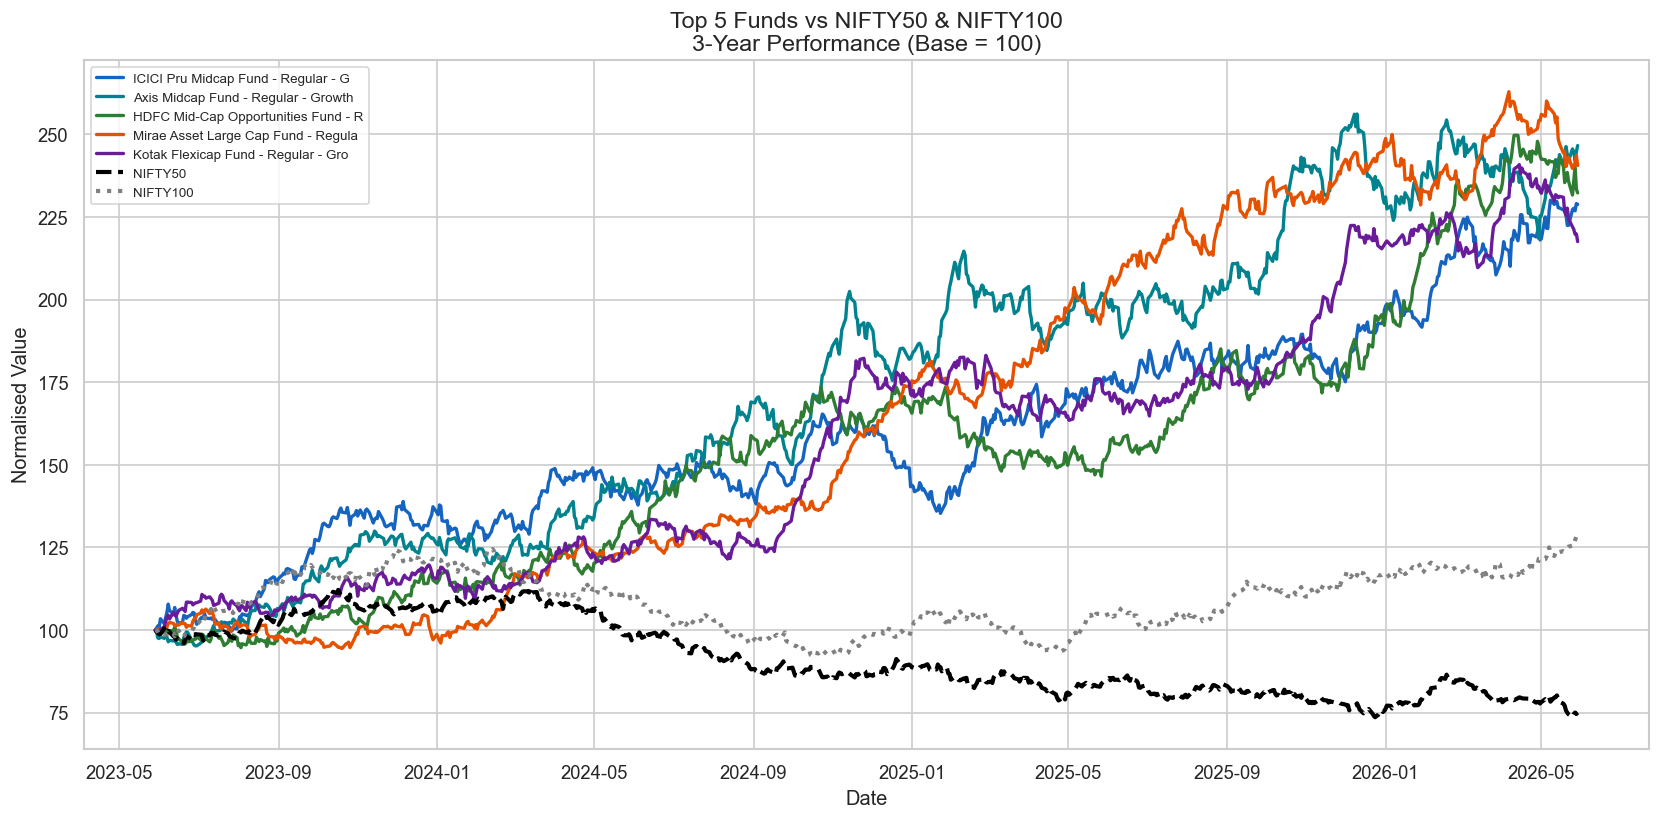

 benchmark_chart.png saved


In [19]:
# ==========================================
# Benchmark Comparison Chart
# Top 5 Funds vs NIFTY50 & NIFTY100
# ==========================================

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd

# Top 5 funds from scorecard
top5_codes = scorecard.head(5)['amfi_code'].tolist()
top5_names = scorecard.head(5)['scheme_name'].tolist()

# Last 3 years data
three_yr_start = nav['date'].max() - pd.DateOffset(years=3)

# Filter NAV data
nav_top5 = nav[
    (nav['amfi_code'].isin(top5_codes)) &
    (nav['date'] >= three_yr_start)
].copy()

# Normalise fund NAV to 100
def normalise(group):
    group = group.sort_values('date').copy()
    group['nav_normalised'] = (
        group['nav'] / group['nav'].iloc[0]
    ) * 100
    return group

nav_top5 = (
    nav_top5
    .groupby('amfi_code', group_keys=False)
    .apply(normalise)
)

nav_top5 = nav_top5.merge(
    funds[['amfi_code', 'scheme_name']],
    on='amfi_code',
    how='left'
)

# ==========================================
# Benchmark Processing
# ==========================================

nifty50 = bench[
    bench['index_name'] == 'NIFTY50'
].copy()

nifty100 = bench[
    bench['index_name'] == 'NIFTY100'
].copy()

# Date conversion
nifty50['date'] = pd.to_datetime(nifty50['date'])
nifty100['date'] = pd.to_datetime(nifty100['date'])

# Last 3 years only
nifty50_3yr = nifty50[
    nifty50['date'] >= three_yr_start
].copy()

nifty100_3yr = nifty100[
    nifty100['date'] >= three_yr_start
].copy()

# Normalise benchmark to 100
nifty50_3yr['nav_normalised'] = (
    nifty50_3yr['close_value']
    / nifty50_3yr['close_value'].iloc[0]
) * 100

nifty100_3yr['nav_normalised'] = (
    nifty100_3yr['close_value']
    / nifty100_3yr['close_value'].iloc[0]
) * 100

# ==========================================
# Plot
# ==========================================

fig, ax = plt.subplots(figsize=(14, 7))

colors = [
    '#1565C0',
    '#00838F',
    '#2E7D32',
    '#E65100',
    '#6A1B9A'
]

for i, code in enumerate(top5_codes):

    fund_data = nav_top5[
        nav_top5['amfi_code'] == code
    ]

    ax.plot(
        fund_data['date'],
        fund_data['nav_normalised'],
        color=colors[i],
        linewidth=2,
        label=top5_names[i][:35]
    )

# NIFTY50
ax.plot(
    nifty50_3yr['date'],
    nifty50_3yr['nav_normalised'],
    color='black',
    linewidth=2.5,
    linestyle='--',
    label='NIFTY50'
)

# NIFTY100
ax.plot(
    nifty100_3yr['date'],
    nifty100_3yr['nav_normalised'],
    color='grey',
    linewidth=2.5,
    linestyle=':',
    label='NIFTY100'
)

ax.set_title(
    'Top 5 Funds vs NIFTY50 & NIFTY100\n3-Year Performance (Base = 100)',
    fontsize=14
)

ax.set_xlabel('Date')
ax.set_ylabel('Normalised Value')

ax.legend(
    loc='upper left',
    fontsize=8
)

ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(
        lambda x, _: f'{x:.0f}'
    )
)

plt.tight_layout()

plt.savefig(
    CHARTS / "benchmark_chart.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print(" benchmark_chart.png saved")

In [22]:
# ==========================================
# Prepare NIFTY100 Benchmark Returns
# ==========================================

nifty100 = bench[
    bench['index_name'] == 'NIFTY100'
].copy()

nifty100['date'] = pd.to_datetime(
    nifty100['date']
)

nifty100 = nifty100.sort_values(
    'date'
)

nifty100['bench_return'] = (
    nifty100['close_value']
    .pct_change()
)

nifty100 = nifty100.dropna(
    subset=['bench_return']
)

print(
    f"NIFTY100 benchmark rows: {len(nifty100)}"
)

print(
    nifty100[
        ['date', 'close_value', 'bench_return']
    ].head()
)

NIFTY100 benchmark rows: 1149
           date  close_value  bench_return
1151 2022-01-04     17537.52     -0.013540
1152 2022-01-05     17607.73      0.004003
1153 2022-01-06     17556.05     -0.002935
1154 2022-01-07     17664.02      0.006150
1155 2022-01-10     17516.51     -0.008351


In [23]:
# ==========================================
# Tracking Error vs NIFTY100
# ==========================================

print("\n— Tracking Error (vs NIFTY100) —\n")

for code in top5_codes:

    fund_ret = returns_df[
        returns_df['amfi_code'] == code
    ][['date', 'daily_return']]

    merged_te = fund_ret.merge(
        nifty100[['date', 'bench_return']],
        on='date',
        how='inner'
    )

    if len(merged_te) < 30:
        continue

    diff = (
        merged_te['daily_return']
        - merged_te['bench_return']
    )

    tracking_error = (
        diff.std()
        * np.sqrt(252)
        * 100
    )

    name = funds[
        funds['amfi_code'] == code
    ]['scheme_name'].values[0]

    print(
        f"{name[:45]:<45} "
        f"Tracking Error = {tracking_error:.2f}%"
    )


— Tracking Error (vs NIFTY100) —

ICICI Pru Midcap Fund - Regular - Growth      Tracking Error = 23.20%
Axis Midcap Fund - Regular - Growth           Tracking Error = 23.77%
HDFC Mid-Cap Opportunities Fund - Regular - G Tracking Error = 22.87%
Mirae Asset Large Cap Fund - Regular - Growth Tracking Error = 18.97%
Kotak Flexicap Fund - Regular - Growth        Tracking Error = 20.64%


In [24]:
# Merge everything into one final summary
final_metrics = scorecard[['amfi_code','scheme_name','fund_house','category',
                            'expense_ratio_pct','score_0_100',
                            'cagr_3yr_pct','sharpe_ratio','alpha_annual',
                            'max_drawdown_pct']].copy()

final_metrics = final_metrics.merge(
    sortino_df[['amfi_code','sortino_ratio']], on='amfi_code', how='left')

# Pretty print top 10
print("═"*100)
print(f"{'Rank':<5} {'Scheme':<40} {'Score':<7} {'CAGR3Y%':<9} {'Sharpe':<8} {'Alpha%':<8} {'MaxDD%':<9} {'Sortino':<8}")
print("═"*100)
for rank, row in final_metrics.head(10).iterrows():
    print(f"{rank:<5} {str(row['scheme_name'])[:38]:<40} "
          f"{row['score_0_100']:<7} {row['cagr_3yr_pct']:<9} "
          f"{row['sharpe_ratio']:<8} {row['alpha_annual']:<8} "
          f"{row['max_drawdown_pct']:<9} {row['sortino_ratio']:<8}")

final_metrics.to_csv(PROCESSED / "final_performance_metrics.csv", index=False)
print("\nSaved final_performance_metrics.csv")

════════════════════════════════════════════════════════════════════════════════════════════════════
Rank  Scheme                                   Score   CAGR3Y%   Sharpe   Alpha%   MaxDD%    Sortino 
════════════════════════════════════════════════════════════════════════════════════════════════════
0     ICICI Pru Midcap Fund - Regular - Grow   100.0   31.78     1.1801   29.2636  -18.19    2.0294  
1     Axis Midcap Fund - Regular - Growth      94.2    35.11     0.9982   26.0767  -20.96    1.7038  
2     HDFC Mid-Cap Opportunities Fund - Regu   93.8    32.44     1.0937   27.1954  -16.22    1.8291  
3     Mirae Asset Large Cap Fund - Regular -   93.0    34.0      1.4483   26.9838  -11.27    2.3856  
4     Kotak Flexicap Fund - Regular - Growth   90.3    29.58     1.3067   27.3305  -12.97    2.3643  
5     ICICI Pru Bluechip Fund - Direct - Gro   86.5    32.49     1.0265   21.1948  -12.59    1.8053  
6     SBI Small Cap Fund - Regular Plan - Gr   85.5    26.67     0.9453   30.337   -

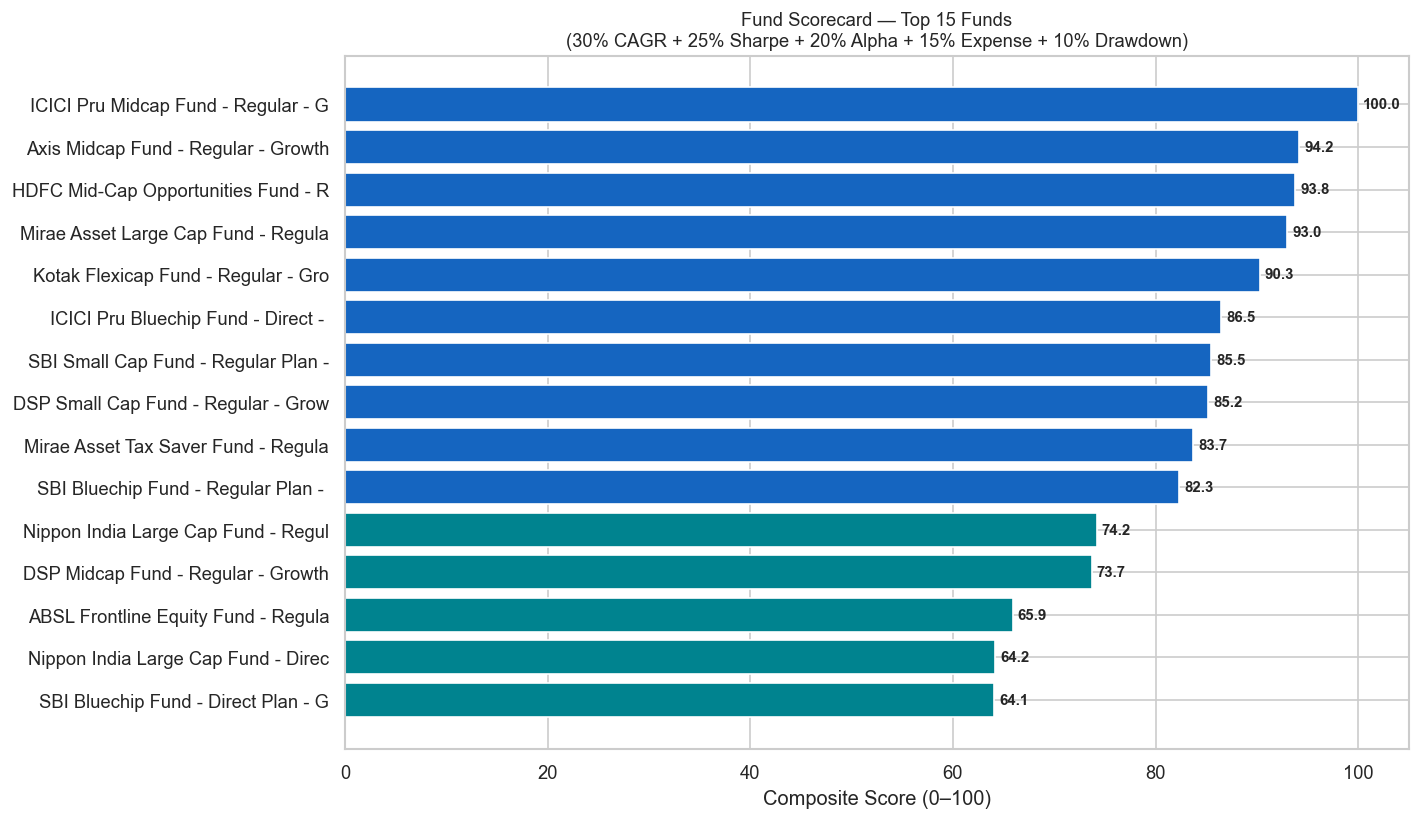

 fund_scorecard_chart.png saved


In [25]:
top15 = scorecard.head(15).copy()

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(top15['scheme_name'].str[:35][::-1],
               top15['score_0_100'][::-1],
               color=[('#1565C0' if s >= 75 else '#00838F' if s >= 50 else '#F57F17')
                      for s in top15['score_0_100'][::-1]])

ax.set_xlabel('Composite Score (0–100)')
ax.set_title('Fund Scorecard — Top 15 Funds\n(30% CAGR + 25% Sharpe + 20% Alpha + 15% Expense + 10% Drawdown)', fontsize=11)
for bar, score in zip(bars, top15['score_0_100'][::-1]):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{score:.1f}', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(CHARTS / "fund_scorecard_chart.png", bbox_inches='tight', dpi=150)
plt.show()
print(" fund_scorecard_chart.png saved")